In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('E-commerce Dataset.csv')

In [80]:
df.head()

,Order_Date,Time,Aging,Customer_Id,Gender,Device_Type,Customer_Login_type,Product_Category,Product,Sales,Quantity,Discount,Profit,Shipping_Cost,Order_Priority,Payment_method,Month
0,2018-01-02,10:56:33,8.0,37077,Female,Web,Member,Auto & Accessories,Car Media Players,140.0,1.0,0.3,46.0,4.6,Medium,credit_card,January
1,2018-07-24,20:41:37,2.0,59173,Female,Web,Member,Auto & Accessories,Car Speakers,211.0,1.0,0.3,112.0,11.2,Medium,credit_card,July
2,2018-11-08,08:38:49,8.0,41066,Female,Web,Member,Auto & Accessories,Car Body Covers,117.0,5.0,0.1,31.2,3.1,Critical,credit_card,November
3,2018-04-18,19:28:06,7.0,50741,Female,Web,Member,Auto & Accessories,Car & Bike Care,118.0,1.0,0.3,26.2,2.6,High,credit_card,April
4,2018-08-13,21:18:39,9.0,53639,Female,Web,Member,Auto & Accessories,Tyre,250.0,1.0,0.3,160.0,16.0,Critical,credit_card,August


In [81]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Time'] = pd.to_datetime(df['Time'])

/tmp/ipython-input-2041229924.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'])


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37231 entries, 0 to 37231
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Order_Date           37231 non-null  datetime64[ns]
 1   Time                 37231 non-null  datetime64[ns]
 2   Aging                37230 non-null  float64       
 3   Customer_Id          37231 non-null  int64         
 4   Gender               37231 non-null  object        
 5   Device_Type          37230 non-null  object        
 6   Customer_Login_type  37230 non-null  object        
 7   Product_Category     37230 non-null  object        
 8   Product              37230 non-null  object        
 9   Sales                37229 non-null  float64       
 10  Quantity             37228 non-null  float64       
 11  Discount             37229 non-null  float64       
 12  Profit               37230 non-null  float64       
 13  Shipping_Cost        37229 non-null 

### Order Date and Time are in datetime dtype so it is fine and rest of the data dtype are also good .....so lets find the no. of null values

In [87]:
df.isnull().sum()

,0
Order_Date,0
Time,0
Aging,1
Customer_Id,0
Gender,0
Device_Type,1
Customer_Login_type,1
Product_Category,1
Product,1
Sales,2


### Only less no.of values are missing in each columns so its better to drop

In [88]:
df.dropna(inplace=True)

### Also better to drop dulpicate value to get better model

In [90]:
df.drop_duplicates(inplace= True)

In [92]:
df = df.reset_index()

## Univariate Analysis

### Lets check which gender has made more orders

In [10]:
df[['Gender']].value_counts()

,count
Gender,
Male,21390
Female,15841
Fem,1


### There is 1 value with female gender as fem so I am changing its title

In [13]:
df[['Gender']] = df[['Gender']].replace('Fem','Female')

In [14]:
df['Gender'].value_counts()

,count
Gender,
Male,21390
Female,15842


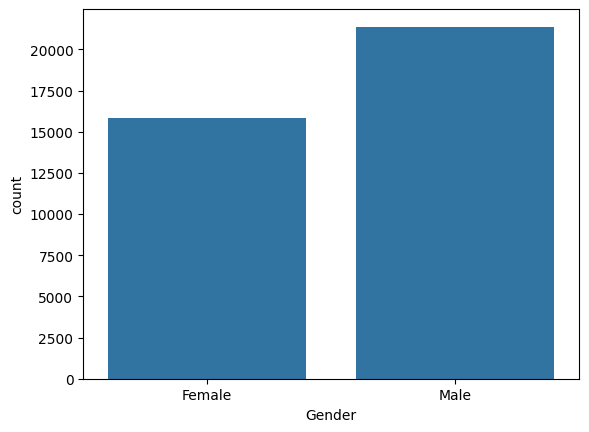

In [110]:
sns.countplot(data=df, x='Gender')
plt.show()

### Observation :
      

*   So male make more orders compared to female




### Let's check on what device the customers make more orders

In [17]:
df[['Device_Type']].value_counts()

,count
Device_Type,
Web,34403
Mobile,2828


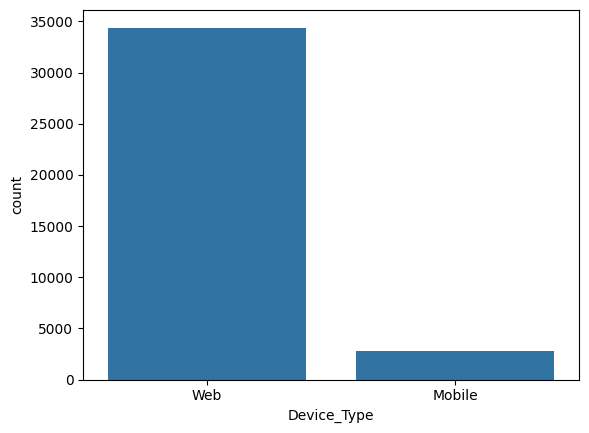

In [109]:
sns.countplot(data=df, x= 'Device_Type')
plt.show()

### Observation :
*   So people make more orders using web and not mobile




## Lets which product category made more sales

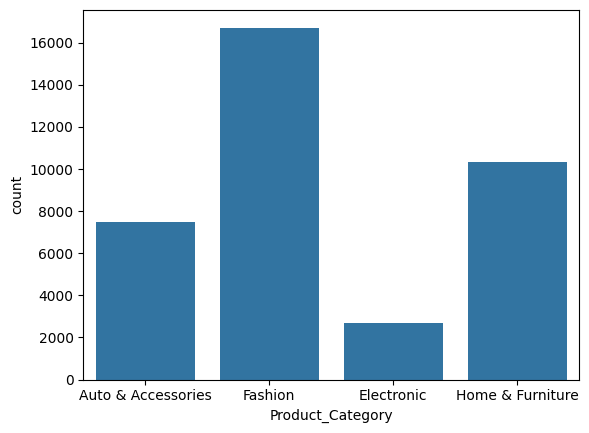

In [108]:
sns.countplot(data = df , x='Product_Category')
plt.show()

### Okay Fashion make more sales in the e commerece platfrom

In [101]:
data = df['Payment_method'].value_counts().reset_index()
data

,Payment_method,count
0,credit_card,27714
1,money_order,6975
2,e_wallet,2005
3,debit_card,528


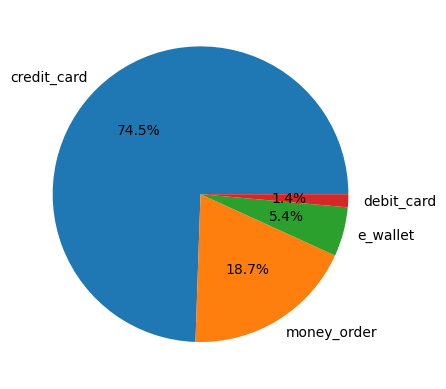

In [107]:
plt.pie(data['count'],labels = data['Payment_method'], autopct='%1.1f%%')
plt.show()

### Nealy 75% of the customer use credit card to purchase

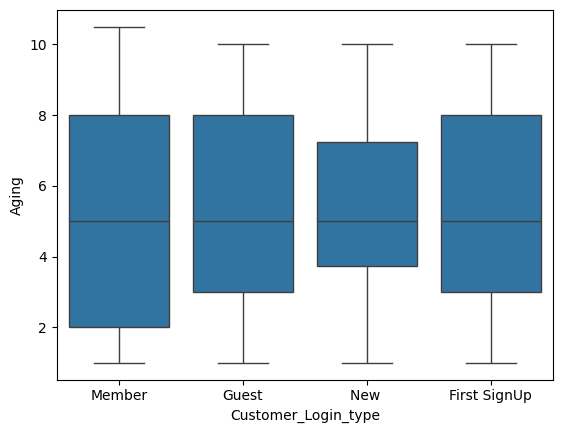

In [119]:
sns.boxplot(data = df , y='Aging', x ='Customer_Login_type')
plt.show()

### So basically they take min of 1 days to deliver and take average of 5 day to deliver the product irrespective of the login type of the customers

## Bivariate Analysis

In [30]:
df1 = df[['Product_Category','Profit']].groupby('Product_Category')['Profit'].sum().reset_index()
df1

,Product_Category,Profit
0,Auto & Accessories,484313.2
1,Electronic,174190.6
2,Fashion,1350875.3
3,Home & Furniture,587614.3


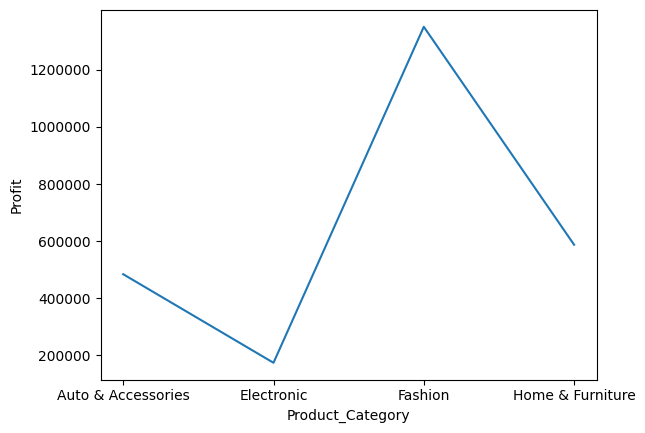

In [39]:
ax = sns.lineplot(data = df1 , x='Product_Category', y='Profit')
plt.yticks(range(200000,1400000,200000))
plt.ticklabel_format(style='plain', axis='y')
plt.show()

### So Fashion product gives more profits

### Lets check Gender Distribution by Product_Category

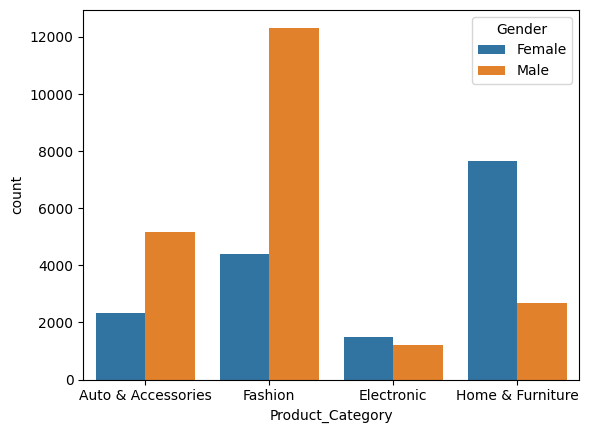

In [120]:
sns.countplot(data=df , x='Product_Category',hue='Gender')
plt.show()

### Observation :                   
*   Even in fashion product men were the one who purchased more and only in Electronis product women bought more than male but not significantly higher




In [65]:
df['Order_Date'].dt.year.value_counts()

,count
Order_Date,
2018,37231


### Since the data have only the year 2018 lets analysis the data based on months

In [71]:
df['Month'] = df['Order_Date'].dt.month_name()
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

In [129]:
df2 = df[['Month','Sales']].groupby('Month')['Sales'].sum().reset_index()
df2


/tmp/ipython-input-320842999.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2 = df[['Month','Sales']].groupby('Month')['Sales'].sum().reset_index()


,Month,Sales
0,January,278852.0
1,February,228707.0
2,March,318810.0
3,April,443537.0
4,May,601975.0
5,June,459207.0
6,July,579147.0
7,August,482284.0
8,September,529043.0
9,October,533861.0


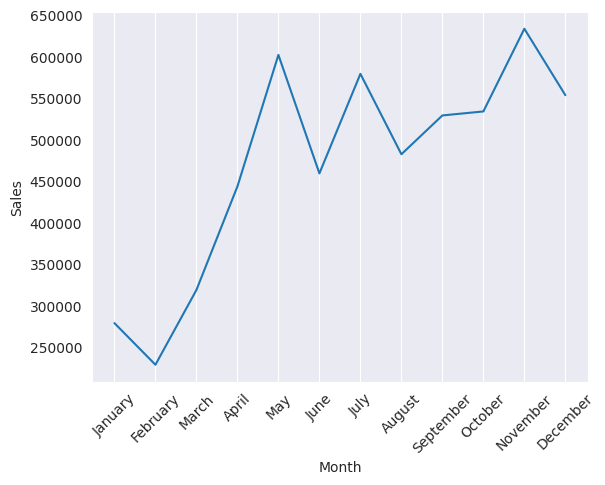

In [135]:
sns.lineplot(data = df2 , x='Month', y='Sales')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

### There is high sales on April to May , July to August and November to December

#### relationship between sales vs profit

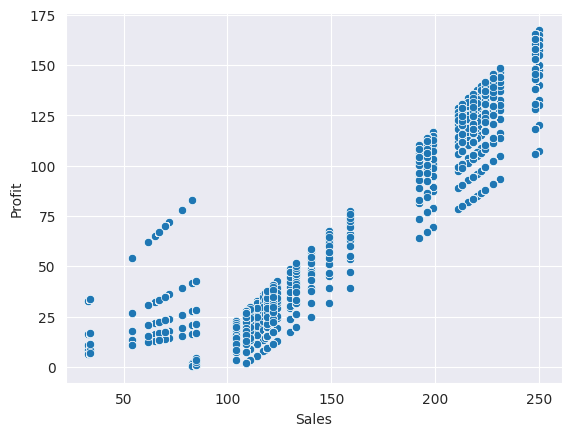

In [136]:
sns.scatterplot(data = df , x='Sales', y ='Profit')
plt.show()

#### for higher sales means higher profits for the platform

## Multivariate Analysis

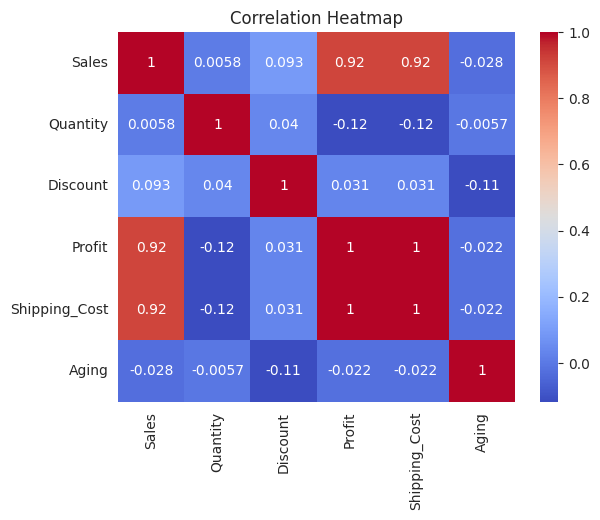

In [137]:
corr_matrix = df[['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping_Cost', 'Aging']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

#### Sales and Profit are highly corelated with value 0.92 and profit and shipping cost are perfect 1 ...so it is better one column before feedding it into model to avoid overfitting and multicollinarity

## Key Findings:

1.   Male customers where the one who make large orders even in Fashion products
2.   Out of all the category, Fashion is the with highest sale
1.   75 % Customers use credit card to make the purchase
2.   Average of 4 to 5 days where taken to deliver the order irrespective of login type of customers
1.   Between October to November there is a huge sale and in april to may and june to july there is a spike in sales and Feb got the  lowest sales
2.   From the heatmap we can say that high Sales means high profit , and also we can come to conclusion that in this case discount is not highly related with profit





